* Given our signals and our estimate of asset volatility, how much risk (weight) should we allocate to each asset?
* We have a trend signal that we built in 03_trend_signals.ipynb
* We now want to descide how we allocate to those signals
* We can use the vol to scale the weights:
$$w_{i,t} = \phi_{i,t-1} \frac{\sigma}{ \hat{\sigma}_{i,t-1}} $$
where $\sigma$ is our target vol and $\hat{\sigma}_{i,t-1}$ is our rolling vol estimate.


In [ ]:
import os
import pandas as pd
import matplotlib.pyplot as plt
from quant.config.strategy import (
    TRADING_DAYS,
    TARGET_VOL_ANN,
    VOL_FLOOR_ANN,
    WEIGHT_CAP,
    MAX_GROSS,
    VOL_WINDOW,
    MIN_PERIODS,
)
from quant.utils.alignment import align_on_index_and_columns
from quant.analytics.asset_volatility import rolling_vol, vol_floor
from quant.utils.timing import lag_for_trading  # your shift helper
from quant.portfolios.weights import asset_vol_target_weights

os.chdir("..")

In [2]:
returns = pd.read_parquet("data/processed/prices_simple_returns.parquet")
signal = pd.read_parquet("data/processed/signals_trend.parquet")
print("returns:", returns.shape, "signal:", signal.shape)

returns: (5022, 15) signal: (5023, 15)


In [3]:
# Align the signal and returns of index and columns
returns, signal, audit = align_on_index_and_columns(
    returns,
    signal,
    name_a="returns",
    name_b="signal",
    audit=True,
)

=== Alignment audit ===
returns dates: 5,022 | signal dates: 5,023 | Common: 5,022
returns cols : 15 | signal cols : 15 | Common: 15

Dates only in returns: 0
Dates only in signal: 1
  first: 2007-01-01 00:00:00  last: 2007-01-01 00:00:00

Tickers only in returns: 0
Tickers only in signal: 0


In [ ]:
# Compute rolling vol (and make it “tradable”)

vol_ann = rolling_vol(
    returns=returns,
    window=VOL_WINDOW,
    periods_per_year=TRADING_DAYS,
    min_periods=MIN_PERIODS,
)

# 2) make it tradable for day t (known at end of t-1)
vol_ann_tm1 = lag_for_trading(vol_ann, lag=1)

# 3) prevent crazy leverage
vol_ann_tm1 = vol_floor(vol_ann_tm1, floor=VOL_FLOOR_ANN)

print("Vol NaN rate:", float(vol_ann_tm1.isna().mean().mean()))
print(
    "Vol min/median/max:",
    float(vol_ann_tm1.stack().min()),
    float(vol_ann_tm1.stack().median()),
    float(vol_ann_tm1.stack().max()),
)

Vol NaN rate: 0.007155183857692819
Vol min/median/max: 0.023657857279016165 0.1087512629976768 7.023592320975762


In [ ]:
w = asset_vol_target_weights(
    signal_lagged=signal,  # already clipped + lagged from 03
    vol_lagged=vol_ann_tm1,  # shifted by 1 in 04
    target_vol=TARGET_VOL_ANN,
    weight_cap=WEIGHT_CAP,
    max_gross=None,
)

In [6]:
print("weights shape:", w.shape)
print("max abs weight:", float(w.abs().max().max()))
print("avg gross:", float(w.abs().sum(axis=1).mean()))
print("max gross:", float(w.abs().sum(axis=1).max()))
print(w.abs().sum(axis=1))

weights shape: (5022, 15)
max abs weight: 2.0
avg gross: 9.296233865776049
max gross: 16.315900711765632
2007-01-02     0.000000
2007-01-03     0.000000
2007-01-04     0.000000
2007-01-05     0.000000
2007-01-08     0.000000
                ...    
2025-12-25    11.007846
2025-12-26    10.999758
2025-12-29    11.201193
2025-12-30    11.235051
2025-12-31    11.296628
Length: 5022, dtype: float64


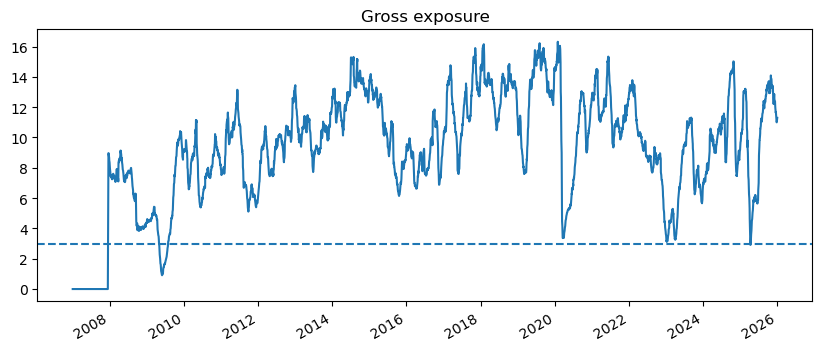

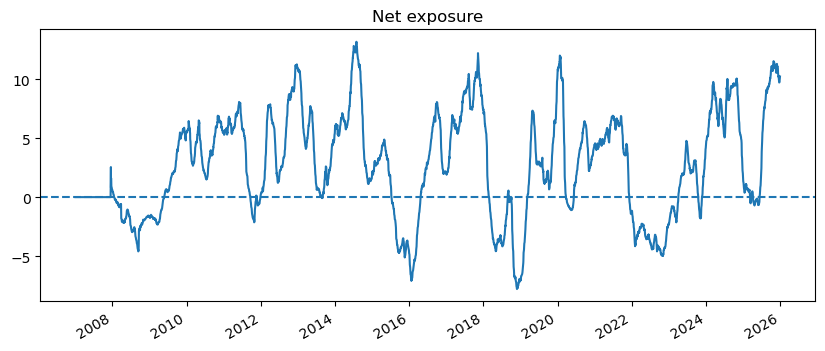

In [ ]:
gross = w.abs().sum(axis=1)
net = w.sum(axis=1)

fig, ax = plt.subplots(figsize=(10, 4))
gross.plot(ax=ax)
ax.axhline(MAX_GROSS, linestyle="--")
ax.set_title("Gross exposure")
plt.show()

fig, ax = plt.subplots(figsize=(10, 4))
net.plot(ax=ax)
ax.axhline(0, linestyle="--")
ax.set_title("Net exposure")
plt.show()

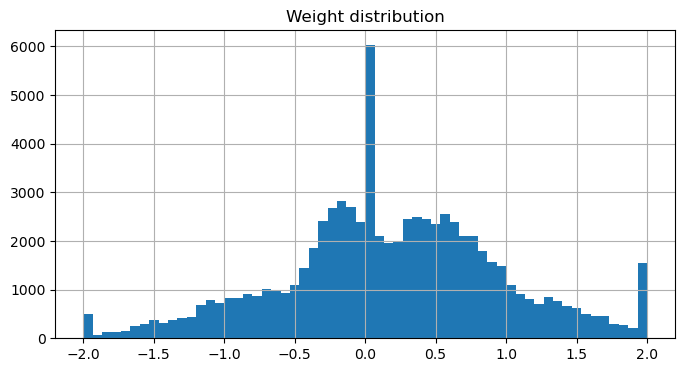

In [8]:
fig, ax = plt.subplots(figsize=(8, 4))
w.stack().hist(ax=ax, bins=60)
ax.set_title("Weight distribution")
plt.show()

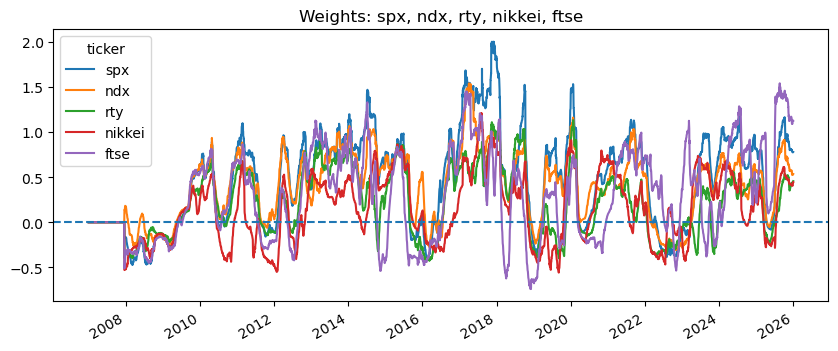

In [9]:
tickers = w.columns[:5]
fig, ax = plt.subplots(figsize=(10, 4))
w[tickers].plot(ax=ax)
ax.axhline(0, linestyle="--")
ax.set_title(f"Weights: {', '.join(tickers)}")
plt.show()

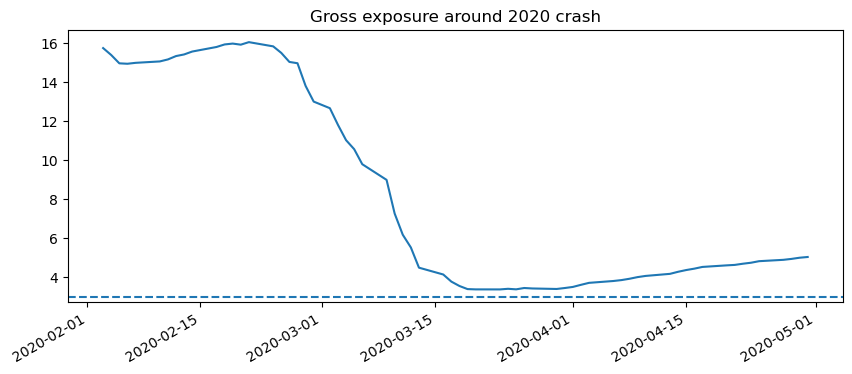

In [10]:
# Because signal is lagged and vol is lagged, you should not see “magical” de-risking before shocks. A quick check:

# pick a volatile period
subset = w.loc["2020-02-01":"2020-04-30"]
subset.abs().sum(axis=1).plot(figsize=(10, 4), title="Gross exposure around 2020 crash")
plt.axhline(MAX_GROSS, linestyle="--")
plt.show()

In [11]:
vol_ann_tm1.to_parquet("data/processed/vol_rolling_60d_ann_tm1.parquet")
w.to_parquet("data/derived/weights_vol_target.parquet")